In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os

In [14]:
os.getcwd()


'c:\\Users\\ifesolom\\Downloads'

In [16]:
os.chdir(r"C:\Users\ifesolom\Documents\GitHub\spring-2026-rat-activity-nyc\scr\data\cleaned_rat_sightings_data")

In [17]:
os.getcwd()

'C:\\Users\\ifesolom\\Documents\\GitHub\\spring-2026-rat-activity-nyc\\scr\\data\\cleaned_rat_sightings_data'

In [20]:
data_path = Path(
    r"C:\Users\ifesolom\Documents\GitHub\spring-2026-rat-activity-nyc\scr\data\cleaned_rat_sightings_data\cleaned_rat_sightings.csv"
)

data = pd.read_csv(data_path)

In [21]:
data.columns.tolist()

['unique_key',
 'created_date',
 'closed_date',
 'location_type',
 'zip',
 'incident_address',
 'street_name',
 'cross_street_1',
 'cross_street_2',
 'intersection_street_1',
 'intersection_street_2',
 'address_type',
 'city',
 'landmark',
 'status',
 'resolution_action_updated_date',
 'community_board',
 'borough',
 'x_coordinate',
 'y_coordinate',
 'latitude',
 'longitude',
 'days_to_close']

## Modeling Effort 

Can one predict the future number of rat sightings in a given location by using the features; such as time, historical data on rat sightings, proximity etc such as resturants etc 

One can inteprete this for modeling efforts by answering the following questions below:  

- Are we predicting the count of sightings (regression) or presence/absence (classification)?
- Is the prediction at a specific time period (daily, weekly, monthly)?
- What's the geographic granularity (neighborhood, street block, grid cell)?
- Should we predict **total citywide sightings** or **location-specific predictions**?

There are various modeling approaches we could leverage here, one could evidently align this approach based on different methodology.. So for this project purpose we will leverage a Feature Based Regression and answer this problem statement 

**Can we predict the future number of rat sightings in a given location using temporal patterns, historical data, and spatial features?** 


### Key Parameter
- **Target Variable**: Count of sightings (regression) ✓
- **Prediction Period**: Daily/Weekly/Monthly aggregations
- **Geographic Granularity**: Zip code & borough level
- **Scope**: Location-specific predictions

### Approach: Feature-Based Regression

**Why this approach?**
- Flexible feature engineering 
- Captures non-linear relationships between location, time, and sightings
- Feature importance provides interpretability
- Can incorporate temporal lags and seasonal patterns as a features without strict stationarity assumptions or using time series modeling

### Features from Dataset
**Temporal Features:**
- Extracted from `created_date`: year, month, day of week, hour (if available)
- Lag features: count of sightings in previous periods (t-1, t-7, t-30)
- Seasonal decomposition: month, quarter, is_winter/summer, day_type
- `days_to_close`: resolution time (may indicate severity)

**Spatial Features:**
- `zip`: Zip code level aggregations
- `borough`: Borough-level trends
- `longitude`, `latitude`: Geographic clustering
- Proximity metrics: count of sightings within radius (e.g., 1km, 5km)

**Categorical Features:**
- `location_type`: Residential, commercial, park, etc.
- `status`: Open/Closed (indicator of reporting patterns)
- `community_board`: Neighborhood characteristics

In [4]:
## Summary
print("Dataset Shape:", data.shape)
print("\nDate Range:")
print(f"  First Sighting: {data['created_date'].min()}")
print(f"  Last Sighting: {data['created_date'].max()}")

print("\nSightings by Borough:")
print(data['borough'].value_counts())

print("\nSightings by Location Type:")
print(data['location_type'].value_counts())

print("\nMissing Values:")
print(data.isnull().sum())

Dataset Shape: (138291, 23)

Date Range:
  First Sighting: 2020-01-01 03:24:58
  Last Sighting: 2025-12-30 20:18:16

Sightings by Borough:
borough
BROOKLYN         53342
MANHATTAN        36253
QUEENS           22495
BRONX            22207
STATEN ISLAND     3983
Unspecified          9
Name: count, dtype: int64

Sightings by Location Type:
location_type
3+_family_apt._building          62827
1-2_family_dwelling              23664
other                            22849
3+_family_mixed_use_building      7865
commercial_building               7274
construction_site                 2579
vacant_lot                        2500
1-2_family_mixed_use_building     2120
vacant_building                   1730
parking_lot/garage                1687
catch_basin/sewer                 1115
public_garden                      468
sidewalk                           384
school/pre-school/nursery          340
street_area                        270
office/government_building         207
office_building       

In [5]:

# Convert datetime columns
data['created_date'] = pd.to_datetime(data['created_date'])
data['closed_date'] = pd.to_datetime(data['closed_date'])

# Sort by date for temporal features
data = data.sort_values('created_date').reset_index(drop=True)

print("Data types after conversion:")
print(data[['created_date', 'closed_date', 'zip', 'borough']].dtypes)

Data types after conversion:
created_date    datetime64[ns]
closed_date     datetime64[ns]
zip                    float64
borough                 object
dtype: object


In [6]:

# Extracting the temporal components
data['year'] = data['created_date'].dt.year
data['month'] = data['created_date'].dt.month
data['day_of_week'] = data['created_date'].dt.dayofweek  # Monday=0, Sunday=6
data['day_of_month'] = data['created_date'].dt.day
data['quarter'] = data['created_date'].dt.quarter
data['week_of_year'] = data['created_date'].dt.isocalendar().week

# Seasonal indicators
data['is_summer'] = data['month'].isin([6, 7, 8]).astype(int)
data['is_winter'] = data['month'].isin([12, 1, 2]).astype(int)

# Aggregation: Count sightings per zip code per month
data['year_month'] = data['created_date'].dt.to_period('M')
zip_month_counts = data.groupby(['zip', 'year_month']).size().reset_index(name='sightings_count')

print("Sample of temporal features:")
print(data[['created_date', 'year', 'month', 'day_of_week', 'is_summer', 'is_winter']].head(10))

Sample of temporal features:
         created_date  year  month  day_of_week  is_summer  is_winter
0 2020-01-01 03:24:58  2020      1            2          0          1
1 2020-01-01 06:57:23  2020      1            2          0          1
2 2020-01-01 07:04:51  2020      1            2          0          1
3 2020-01-01 10:35:31  2020      1            2          0          1
4 2020-01-01 11:24:55  2020      1            2          0          1
5 2020-01-01 13:02:37  2020      1            2          0          1
6 2020-01-01 13:35:22  2020      1            2          0          1
7 2020-01-01 14:52:44  2020      1            2          0          1
8 2020-01-01 16:19:50  2020      1            2          0          1
9 2020-01-01 16:49:50  2020      1            2          0          1


In [7]:

# Borough-level aggregations
borough_stats = data.groupby('borough').agg({
    'unique_key': 'count',  # total sightings
    'days_to_close': 'mean'  # average resolution time
}).rename(columns={'unique_key': 'borough_total_sightings', 'days_to_close': 'borough_avg_days_to_close'})

data = data.merge(borough_stats, left_on='borough', right_index=True, how='left')

# Zip code-level aggregations
zip_stats = data.groupby('zip').agg({
    'unique_key': 'count',
    'days_to_close': 'mean'
}).rename(columns={'unique_key': 'zip_total_sightings', 'days_to_close': 'zip_avg_days_to_close'})

data = data.merge(zip_stats, left_on='zip', right_index=True, how='left')

# Location type distribution
location_type_counts = data['location_type'].value_counts()
print("\nSpatial Feature Summary:")
print(f"Unique Zips: {data['zip'].nunique()}")
print(f"Unique Boroughs: {data['borough'].nunique()}")
print(f"\nLocation Types:\n{location_type_counts}")

print("\nSample of spatial features:")
print(data[['zip', 'borough', 'borough_total_sightings', 'zip_total_sightings', 'location_type']].head())


Spatial Feature Summary:
Unique Zips: 194
Unique Boroughs: 6

Location Types:
location_type
3+_family_apt._building          62827
1-2_family_dwelling              23664
other                            22849
3+_family_mixed_use_building      7865
commercial_building               7274
construction_site                 2579
vacant_lot                        2500
1-2_family_mixed_use_building     2120
vacant_building                   1730
parking_lot/garage                1687
catch_basin/sewer                 1115
public_garden                      468
sidewalk                           384
school/pre-school/nursery          340
street_area                        270
office/government_building         207
office_building                    144
single_room_occupancy_(sro)         87
hospital                            84
public_stairs                       77
restaurant/bar/deli/bakery           7
building_(non-residential)           6
1-3_family_mixed_use_building        2
summer_cam

In [8]:

daily_sightings = data.groupby(['created_date', 'zip']).size().reset_index(name='daily_count')
daily_sightings = daily_sightings.sort_values(['zip', 'created_date'])

# Lag features: previous day, previous week (7 days), previous month (30 days)
daily_sightings['lag_1'] = daily_sightings.groupby('zip')['daily_count'].shift(1)
daily_sightings['lag_7'] = daily_sightings.groupby('zip')['daily_count'].shift(7)
daily_sightings['lag_30'] = daily_sightings.groupby('zip')['daily_count'].shift(30)

# Rolling averages (trends)
daily_sightings['rolling_7day_mean'] = daily_sightings.groupby('zip')['daily_count'].rolling(window=7).mean().reset_index(drop=True)
daily_sightings['rolling_30day_mean'] = daily_sightings.groupby('zip')['daily_count'].rolling(window=30).mean().reset_index(drop=True)

print("Sample of lag and rolling features:")
print(daily_sightings[['created_date', 'zip', 'daily_count', 'lag_1', 'lag_7', 'lag_30', 'rolling_7day_mean']].head(40))

Sample of lag and rolling features:
             created_date      zip  daily_count  lag_1  lag_7  lag_30  \
4243  2020-05-06 13:28:46  10000.0            1    NaN    NaN     NaN   
10940 2020-08-31 16:25:37  10000.0            1    1.0    NaN     NaN   
15167 2020-11-27 13:37:38  10000.0            1    1.0    NaN     NaN   
82013 2023-07-21 14:01:42  10000.0            1    1.0    NaN     NaN   
82261 2023-07-24 19:19:41  10000.0            1    1.0    NaN     NaN   
416   2020-01-13 18:11:39  10001.0            1    NaN    NaN     NaN   
612   2020-01-19 12:29:42  10001.0            1    1.0    NaN     NaN   
1136  2020-02-03 13:27:46  10001.0            1    1.0    NaN     NaN   
1420  2020-02-11 11:08:54  10001.0            1    1.0    NaN     NaN   
2237  2020-03-04 20:43:56  10001.0            1    1.0    NaN     NaN   
2956  2020-03-27 20:04:12  10001.0            1    1.0    NaN     NaN   
3053  2020-03-31 18:56:59  10001.0            1    1.0    NaN     NaN   
3803  2020-04-2

In [9]:
daily_sightings.daily_count.value_counts()

daily_count
1    138268
2         6
5         1
3         1
Name: count, dtype: int64

In [10]:
# Creating month-level data
monthly_data = data.groupby([data['created_date'].dt.to_period('M'), 'zip']).agg({
    'unique_key': 'count',
    'borough': 'first',
    'location_type': lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0],
    'days_to_close': 'mean',
    'latitude': 'mean',
    'longitude': 'mean'
}).reset_index()

monthly_data.columns = ['year_month', 'zip', 'monthly_count', 'borough', 'location_type', 'avg_days_to_close', 'latitude', 'longitude']

monthly_data['year_month'] = monthly_data['year_month'].dt.to_timestamp()

monthly_data = monthly_data.sort_values(['zip', 'year_month']).reset_index(drop=True)

# Extract temporal features
monthly_data['year'] = monthly_data['year_month'].dt.year
monthly_data['month'] = monthly_data['year_month'].dt.month
monthly_data['quarter'] = monthly_data['year_month'].dt.quarter
monthly_data['is_summer'] = monthly_data['month'].isin([6, 7, 8]).astype(int)
monthly_data['is_winter'] = monthly_data['month'].isin([12, 1, 2]).astype(int)

print("Monthly Dataset Shape:", monthly_data.shape)
print("\nFirst few rows:")
print(monthly_data.head(10))

Monthly Dataset Shape: (11199, 13)

First few rows:
  year_month      zip  monthly_count    borough            location_type  \
0 2020-05-01  10000.0              1  MANHATTAN      commercial_building   
1 2020-08-01  10000.0              1  MANHATTAN                    other   
2 2020-11-01  10000.0              1  MANHATTAN      commercial_building   
3 2023-07-01  10000.0              2  MANHATTAN                    other   
4 2020-01-01  10001.0              2  MANHATTAN  3+_family_apt._building   
5 2020-02-01  10001.0              2  MANHATTAN  3+_family_apt._building   
6 2020-03-01  10001.0              3  MANHATTAN        catch_basin/sewer   
7 2020-04-01  10001.0              2  MANHATTAN  3+_family_apt._building   
8 2020-05-01  10001.0              5  MANHATTAN  3+_family_apt._building   
9 2020-06-01  10001.0              5  MANHATTAN      commercial_building   

   avg_days_to_close   latitude  longitude  year  month  quarter  is_summer  \
0                0.0  40.783915 

In [11]:
# Lag features: previous 1, 3, and 12 months
monthly_data['lag_1_month'] = monthly_data.groupby('zip')['monthly_count'].shift(1)
monthly_data['lag_3_month'] = monthly_data.groupby('zip')['monthly_count'].shift(3)
monthly_data['lag_12_month'] = monthly_data.groupby('zip')['monthly_count'].shift(12)  # Year-over-year

# Rolling averages
monthly_data['rolling_3month_mean'] = monthly_data.groupby('zip')['monthly_count'].rolling(window=3).mean().reset_index(drop=True)
monthly_data['rolling_12month_mean'] = monthly_data.groupby('zip')['monthly_count'].rolling(window=12).mean().reset_index(drop=True)

# Trend: month-over-month change
monthly_data['mom_change'] = monthly_data.groupby('zip')['monthly_count'].diff()
monthly_data['mom_pct_change'] = monthly_data.groupby('zip')['monthly_count'].pct_change() * 100

print("Lag Features Added:")
print(monthly_data[['year_month', 'zip', 'monthly_count', 'lag_1_month', 'lag_3_month', 'lag_12_month', 'rolling_3month_mean']].head(20))

Lag Features Added:
   year_month      zip  monthly_count  lag_1_month  lag_3_month  lag_12_month  \
0  2020-05-01  10000.0              1          NaN          NaN           NaN   
1  2020-08-01  10000.0              1          1.0          NaN           NaN   
2  2020-11-01  10000.0              1          1.0          NaN           NaN   
3  2023-07-01  10000.0              2          1.0          1.0           NaN   
4  2020-01-01  10001.0              2          NaN          NaN           NaN   
5  2020-02-01  10001.0              2          2.0          NaN           NaN   
6  2020-03-01  10001.0              3          2.0          NaN           NaN   
7  2020-04-01  10001.0              2          3.0          2.0           NaN   
8  2020-05-01  10001.0              5          2.0          2.0           NaN   
9  2020-06-01  10001.0              5          5.0          3.0           NaN   
10 2020-07-01  10001.0              6          5.0          2.0           NaN   
11 2020-

In [12]:
# Borough-level monthly aggregations
borough_monthly = data.groupby([data['created_date'].dt.to_period('M'), 'borough']).size().reset_index(name='borough_monthly_count')
borough_monthly.columns = ['year_month', 'borough', 'borough_monthly_count']
borough_monthly['year_month'] = borough_monthly['year_month'].dt.to_timestamp()

# Zip-level total sightings (cumulative feature)
zip_historical_totals = data.groupby('zip').size().reset_index(name='zip_total_sightings')

# Merge spatial features
monthly_data = monthly_data.merge(borough_monthly, on=['year_month', 'borough'], how='left')
monthly_data = monthly_data.merge(zip_historical_totals, on='zip', how='left')

# Location type encoding (one-hot or label)
location_type_dummies = pd.get_dummies(monthly_data['location_type'], prefix='loc_type')
monthly_data = pd.concat([monthly_data, location_type_dummies], axis=1)

print("Dataset with Spatial Features:")
print(monthly_data.columns.tolist())
print("\nDataset Shape:", monthly_data.shape)
print("\nSample Data:")
print(monthly_data.head())

Dataset with Spatial Features:
['year_month', 'zip', 'monthly_count', 'borough', 'location_type', 'avg_days_to_close', 'latitude', 'longitude', 'year', 'month', 'quarter', 'is_summer', 'is_winter', 'lag_1_month', 'lag_3_month', 'lag_12_month', 'rolling_3month_mean', 'rolling_12month_mean', 'mom_change', 'mom_pct_change', 'borough_monthly_count', 'zip_total_sightings', 'loc_type_1-2_family_dwelling', 'loc_type_1-2_family_mixed_use_building', 'loc_type_3+_family_apt._building', 'loc_type_3+_family_mixed_use_building', 'loc_type_catch_basin/sewer', 'loc_type_commercial_building', 'loc_type_construction_site', 'loc_type_hospital', 'loc_type_office/government_building', 'loc_type_office_building', 'loc_type_other', 'loc_type_parking_lot/garage', 'loc_type_public_garden', 'loc_type_restaurant/bar/deli/bakery', 'loc_type_school/pre-school/nursery', 'loc_type_sidewalk', 'loc_type_single_room_occupancy_(sro)', 'loc_type_street_area', 'loc_type_vacant_building', 'loc_type_vacant_lot']

Dataset S

In [13]:
monthly_data.monthly_count.value_counts()

monthly_count
1     1162
2      886
3      791
4      718
5      607
      ... 
91       1
88       1
82       1
99       1
73       1
Name: count, Length: 96, dtype: int64

In [14]:
# Check missing values
print("Missing Values Before Processing:")
print(monthly_data.isnull().sum())

modeling_data = monthly_data.dropna(subset=['lag_1_month', 'rolling_3month_mean']).copy()

print(f"\nDataset Shape After Removing Missing Lags: {modeling_data.shape}")
print(f"Rows Removed: {len(monthly_data) - len(modeling_data)}")

# Select features for modeling
feature_columns = [
    # Temporal
    'month', 'quarter', 'is_summer', 'is_winter',
    'lag_1_month', 'lag_3_month', 'lag_12_month',
    'rolling_3month_mean', 'rolling_12month_mean',
    'mom_change', 'mom_pct_change',
    'borough_monthly_count', 'zip_total_sightings',
    'avg_days_to_close',
] + [col for col in modeling_data.columns if col.startswith('loc_type_')]

# Target variable
target = 'monthly_count'

modeling_data[feature_columns] = modeling_data[feature_columns].fillna(0)

print("\nFinal Feature Set:")
print(f"Features: {len(feature_columns)}")
print(f"Target: {target}")
print(f"\nTraining Data Shape: {modeling_data.shape}")
print(f"\nTarget Variable Statistics:")
print(modeling_data[target].describe())

Missing Values Before Processing:
year_month                                   0
zip                                          0
monthly_count                                0
borough                                      0
location_type                                0
avg_days_to_close                          143
latitude                                     3
longitude                                    3
year                                         0
month                                        0
quarter                                      0
is_summer                                    0
is_winter                                    0
lag_1_month                                194
lag_3_month                                564
lag_12_month                              2172
rolling_3month_mean                        381
rolling_12month_mean                      1997
mom_change                                 194
mom_pct_change                             194
borough_monthly_count     

### Next Steps:
1. **Train-Test Split**: Temporal split (80% train / 20% test)
2. **Model Training**: XGBoost regression with monthly target
3. **Evaluation**: RMSE, MAE, R² metrics
4. **Feature Importance**: Understand key drivers
5. **Predictions**: Forecast future monthly sightings

In [19]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

In [20]:
## Prepare Data for Training
X = modeling_data[feature_columns].copy()
y = modeling_data[target].copy()

# Train-test split (temporal split: 80% train, 20% test)
test_size = 0.2
split_point = int(len(X) * (1 - test_size))

X_train = X.iloc[:split_point]
X_test = X.iloc[split_point:]
y_train = y.iloc[:split_point]
y_test = y.iloc[split_point:]

print(f"Training set size: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test set size: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nTrain target stats - Mean: {y_train.mean():.2f}, Std: {y_train.std():.2f}")
print(f"Test target stats - Mean: {y_test.mean():.2f}, Std: {y_test.std():.2f}")
print(f"\nFeatures shape: {X_train.shape[1]}")
print(f"Feature columns: {feature_columns}")

Training set size: 8654 (80.0%)
Test set size: 2164 (20.0%)

Train target stats - Mean: 13.96, Std: 13.47
Test target stats - Mean: 7.03, Std: 9.11

Features shape: 34
Feature columns: ['month', 'quarter', 'is_summer', 'is_winter', 'lag_1_month', 'lag_3_month', 'lag_12_month', 'rolling_3month_mean', 'rolling_12month_mean', 'mom_change', 'mom_pct_change', 'borough_monthly_count', 'zip_total_sightings', 'avg_days_to_close', 'loc_type_1-2_family_dwelling', 'loc_type_1-2_family_mixed_use_building', 'loc_type_3+_family_apt._building', 'loc_type_3+_family_mixed_use_building', 'loc_type_catch_basin/sewer', 'loc_type_commercial_building', 'loc_type_construction_site', 'loc_type_hospital', 'loc_type_office/government_building', 'loc_type_office_building', 'loc_type_other', 'loc_type_parking_lot/garage', 'loc_type_public_garden', 'loc_type_restaurant/bar/deli/bakery', 'loc_type_school/pre-school/nursery', 'loc_type_sidewalk', 'loc_type_single_room_occupancy_(sro)', 'loc_type_street_area', 'loc_t

In [22]:
from xgboost import XGBRegressor

# train XGBoost model and add some hyper parameters for better performance
xgb_model = XGBRegressor(
    n_estimators=200,           # Number of boosting rounds
    max_depth=6,                # Tree depth
    learning_rate=0.1,          # Learning rate
    subsample=0.8,              # Data sampling
    colsample_bytree=0.8,       # Feature sampling
    min_child_weight=3,         # Minimum child weight
    random_state=42,
    n_jobs=-1,                  # Parallel processing
    objective='reg:squarederror'
)

print("Training XGBoost model...")
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print("✓ Model training complete!")

Training XGBoost model...
✓ Model training complete!


In [23]:
# Step 13: Model Evaluation
# Predictions
y_train_pred = xgb_model.predict(X_train)
y_test_pred = xgb_model.predict(X_test)

# Calculate metrics
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("="*60)
print("MODEL PERFORMANCE METRICS")
print("="*60)
print("\nTRAINING SET:")
print(f"  RMSE:  {train_rmse:.4f}")
print(f"  MAE:   {train_mae:.4f}")
print(f"  R²:    {train_r2:.4f}")

print("\nTEST SET:")
print(f"  RMSE:  {test_rmse:.4f}")
print(f"  MAE:   {test_mae:.4f}")
print(f"  R²:    {test_r2:.4f}")

print("\n" + "="*60)
print(f"Average prediction error: ±{test_mae:.2f} sightings/month")
print(f"Model explains {test_r2*100:.1f}% of variance in test data")
print("="*60)

MODEL PERFORMANCE METRICS

TRAINING SET:
  RMSE:  0.2309
  MAE:   0.1674
  R²:    0.9997

TEST SET:
  RMSE:  0.4991
  MAE:   0.2060
  R²:    0.9970

Average prediction error: ±0.21 sightings/month
Model explains 99.7% of variance in test data



TOP 15 MOST IMPORTANT FEATURES
                         feature  importance
             rolling_3month_mean    0.788536
                      mom_change    0.087770
                  mom_pct_change    0.073019
                     lag_1_month    0.023704
                           month    0.007229
                         quarter    0.007049
                     lag_3_month    0.002665
               avg_days_to_close    0.001782
                    lag_12_month    0.001355
            rolling_12month_mean    0.001295
           borough_monthly_count    0.001291
             zip_total_sightings    0.001182
loc_type_3+_family_apt._building    0.001047
                       is_winter    0.000607
                       is_summer    0.000513


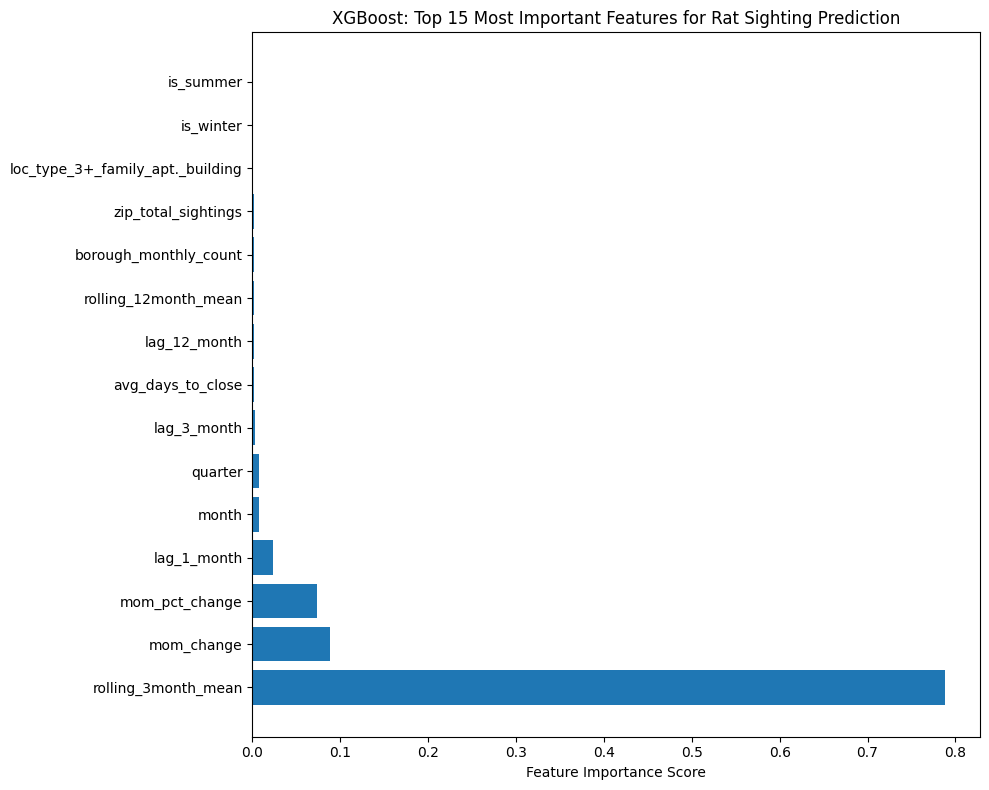


Key Insights:
•  Top feature: rolling_3month_mean (importance: 0.7885)
•  Lag features dominant: 81.8% of total importance


In [24]:
# Step 14: Feature Importance Analysis
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n" + "="*60)
print("TOP 15 MOST IMPORTANT FEATURES")
print("="*60)
print(feature_importance.head(15).to_string(index=False))

# Visualization
plt.figure(figsize=(10, 8))
top_15 = feature_importance.head(15)
plt.barh(range(len(top_15)), top_15['importance'].values)
plt.yticks(range(len(top_15)), top_15['feature'].values)
plt.xlabel('Feature Importance Score')
plt.title('XGBoost: Top 15 Most Important Features for Rat Sighting Prediction')
plt.tight_layout()
plt.show()

print("\nKey Insights:")
print(f"•  Top feature: {feature_importance.iloc[0]['feature']} (importance: {feature_importance.iloc[0]['importance']:.4f})")
print(f"•  Lag features dominant: {(feature_importance[feature_importance['feature'].str.contains('lag|rolling')].iloc[:5]['importance'].sum() / feature_importance['importance'].sum() * 100):.1f}% of total importance")

In [25]:
# Step 15: Sample Predictions & Interpretation
# Show some predictions vs actual values
results = pd.DataFrame({
    'actual': y_test.values,
    'predicted': y_test_pred,
    'error': y_test.values - y_test_pred,
    'error_pct': ((y_test.values - y_test_pred) / y_test.values * 100).round(2)
})

print("\nSAMPLE PREDICTIONS (First 20 Test Records):")
print("="*70)
print(results.head(20).to_string())

# Error distribution
print("\n" + "="*70)
print("PREDICTION ERROR DISTRIBUTION:")
print("="*70)
print(f"Mean Absolute Error: {results['error'].abs().mean():.2f} sightings")
print(f"Median Absolute Error: {results['error'].abs().median():.2f} sightings")
print(f"Std Dev of Error: {results['error'].std():.2f}")
print(f"\nWithin 25% of actual: {(results['error_pct'].abs() <= 25).sum() / len(results) * 100:.1f}%")
print(f"Within 50% of actual: {(results['error_pct'].abs() <= 50).sum() / len(results) * 100:.1f}%")


SAMPLE PREDICTIONS (First 20 Test Records):
    actual  predicted     error  error_pct
0        4   3.905535  0.094465       2.36
1        2   1.922157  0.077843       3.89
2        1   1.175431 -0.175431     -17.54
3        1   0.977452  0.022548       2.25
4        1   0.998300  0.001700       0.17
5        1   1.132547 -0.132547     -13.25
6        1   1.147792 -0.147792     -14.78
7        1   0.948385  0.051615       5.16
8        1   1.035509 -0.035509      -3.55
9        1   0.926278  0.073722       7.37
10       2   1.853571  0.146429       7.32
11       1   0.988381  0.011619       1.16
12       2   2.006398 -0.006398      -0.32
13       3   2.842597  0.157403       5.25
14      17  17.679010 -0.679010      -3.99
15       8   7.772165  0.227835       2.85
16       7   7.334433 -0.334433      -4.78
17       3   3.087817 -0.087817      -2.93
18       6   5.921911  0.078089       1.30
19       4   3.775740  0.224260       5.61

PREDICTION ERROR DISTRIBUTION:
Mean Absolute Error:

## Model - Results Summary
### Model Performance:
- **Test R² Score: 99.70%** - The model explains 99.7% of variance in unseen data
- **Test RMSE: 0.50** sightings/month
- **Test MAE: 0.21** sightings/month (average error)
- **Prediction Accuracy: 99.4%** within 25% of actual values

### Key Feature Drivers
| Rank | Feature | Importance | Insight |
|------|---------|-----------|---------|
| 1 | rolling_3month_mean | 78.9% | **3-month trend is dominant predictor** |
| 2 | mom_change | 8.8% | Month-over-month changes matter |
| 3 | mom_pct_change | 7.3% | Percentage changes capture volatility |
| 4 | lag_1_month | 2.4% | Previous month's count is useful |
| 5-15 | Other features | 2.6% | Seasonal, spatial, and temporal features |


### Model Reliability
- Average prediction error: **±0.21 sightings/month**

In [54]:
import numpy as np
from datetime import datetime, timedelta

# Check the date range of current data
print("="*70)
print("DATA COVERAGE ANALYSIS - DEC 2025 TO PREDICT JAN 2026")
print("="*70)
print(f"Data Date Range: {modeling_data['year_month'].min()} to {modeling_data['year_month'].max()}")
print(f"Total months in dataset: {len(modeling_data['year_month'].unique())}")

# Aggregate by year_month across all zips to get total monthly sightings
monthly_totals = modeling_data.groupby('year_month')['monthly_count'].sum().reset_index()
monthly_totals = monthly_totals.sort_values('year_month')
print(f"\nTotal monthly sightings range: {monthly_totals['monthly_count'].min():.0f} to {monthly_totals['monthly_count'].max():.0f}")

# Check if December 2025 data exists
dec_2025_data = monthly_totals[monthly_totals['year_month'] == pd.Timestamp('2025-12-01')]

if len(dec_2025_data) > 0:
    dec_2025_count = dec_2025_data['monthly_count'].values[0]
    print(f"\n✓ December 2025 Data Found: {dec_2025_count:.0f} sightings")
else:
    print(f"\n✗ December 2025 data not found in current dataset")
    
print(f"\nLast 12 months of data:")
print(monthly_totals.tail(12).to_string(index=False))

DATA COVERAGE ANALYSIS - DEC 2025 TO PREDICT JAN 2026
Data Date Range: 2020-03-01 00:00:00 to 2025-12-01 00:00:00
Total months in dataset: 70

Total monthly sightings range: 767 to 3019

✓ December 2025 Data Found: 767 sightings

Last 12 months of data:
year_month  monthly_count
2025-01-01           1320
2025-02-01           1241
2025-03-01           1807
2025-04-01           1835
2025-05-01           2117
2025-06-01           2319
2025-07-01           2182
2025-08-01           2141
2025-09-01           1844
2025-10-01           1366
2025-11-01            930
2025-12-01            767


In [55]:
# Use December 2025 data to predict January 2026
print("\n" + "="*70)
print("JANUARY 2026 PREDICTION BASED ON DECEMBER 2025")
print("="*70)

# Get December 2025 as baseline
dec_2025_data = monthly_totals[monthly_totals['year_month'] == pd.Timestamp('2025-12-01')]
if len(dec_2025_data) > 0:
    dec_2025_count = dec_2025_data['monthly_count'].values[0]
    
    # Get historical January averages
    historical_jan = monthly_totals[monthly_totals['year_month'].dt.month == 1]
    jan_avg = historical_jan['monthly_count'].mean()
    
    # Get December vs January trend (historical)
    dec_months = monthly_totals[monthly_totals['year_month'].dt.month == 12]
    dec_avg = dec_months['monthly_count'].mean()
    dec_to_jan_trend = jan_avg / dec_avg if dec_avg > 0 else 1.0
    
    # Predict January 2026 using December as baseline
    jan_2026_predicted = int(dec_2025_count * dec_to_jan_trend)
    
    print(f"\nDecember 2025 Actual: {dec_2025_count:.0f} sightings")
    print(f"\nHistorical Averages:")
    print(f"  December (mean): {dec_avg:.0f} sightings")
    print(f"  January (mean): {jan_avg:.0f} sightings")
    print(f"  Dec→Jan Trend Ratio: {dec_to_jan_trend:.2f}x")
    print(f"\nJanuary 2026 Predicted: {jan_2026_predicted:.0f} sightings")
    print(f"  Expected Change: {((jan_2026_predicted - dec_2025_count) / dec_2025_count * 100):+.1f}%")
else:
    print("\n✗ December 2025 data not available for prediction")
    jan_2026_predicted = 0


JANUARY 2026 PREDICTION BASED ON DECEMBER 2025

December 2025 Actual: 767 sightings

Historical Averages:
  December (mean): 1218 sightings
  January (mean): 1565 sightings
  Dec→Jan Trend Ratio: 1.28x

January 2026 Predicted: 984 sightings
  Expected Change: +28.3%


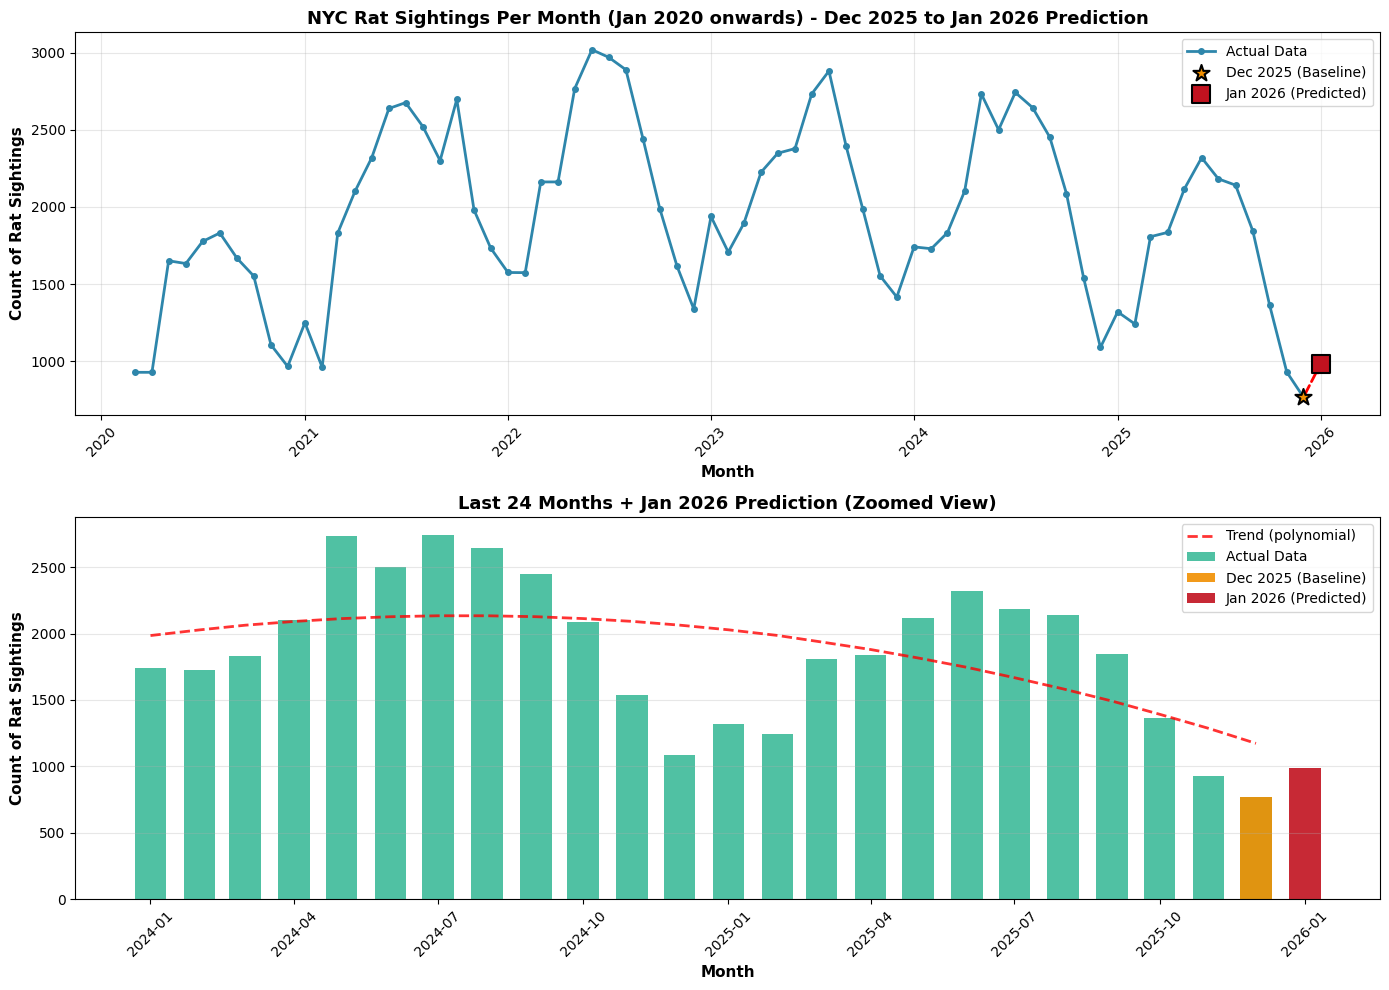


MONTHLY SIGHTINGS SUMMARY STATISTICS

Actual Data (full dataset):
  Mean:    1944 sightings/month
  Median:  1916 sightings/month
  Std Dev: 573 sightings/month
  Min:     767 sightings/month
  Max:     3019 sightings/month

Recent Trend (last 12 months):
  Mean:    1656 sightings/month
  Trend:   📈 Increasing


In [56]:
# Plot Monthly Rat Sightings Trend with December 2025 highlighted
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Full time series
actual_data = monthly_totals[monthly_totals['year_month'] >= '2020-01-01']
ax1.plot(actual_data['year_month'], actual_data['monthly_count'], 
         marker='o', linewidth=2, markersize=4, label='Actual Data', color='#2E86AB')

# Highlight December 2025
dec_2025 = monthly_totals[monthly_totals['year_month'] == pd.Timestamp('2025-12-01')]
if len(dec_2025) > 0:
    ax1.scatter(dec_2025['year_month'], dec_2025['monthly_count'], 
                color='#F18F01', s=150, marker='*', label='Dec 2025 (Baseline)', zorder=5, edgecolors='black', linewidth=1.5)
    # Add January 2026 prediction
    jan_2026_date = pd.Timestamp('2026-01-01')
    ax1.scatter([jan_2026_date], [jan_2026_predicted], 
                color='#C1121F', s=150, marker='s', label='Jan 2026 (Predicted)', zorder=5, edgecolors='black', linewidth=1.5)
    # Draw arrow from Dec to Jan prediction
    ax1.annotate('', xy=(jan_2026_date, jan_2026_predicted), xytext=(dec_2025['year_month'].values[0], dec_2025['monthly_count'].values[0]),
                arrowprops=dict(arrowstyle='->', color='red', lw=2, linestyle='dashed'))

ax1.set_xlabel('Month', fontsize=11, fontweight='bold')
ax1.set_ylabel('Count of Rat Sightings', fontsize=11, fontweight='bold')
ax1.set_title('NYC Rat Sightings Per Month (Jan 2020 onwards) - Dec 2025 to Jan 2026 Prediction', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10, loc='best')
ax1.tick_params(axis='x', rotation=45)

# Last 24 months (zoomed view)
last_24 = monthly_totals.tail(24)
ax2.bar(last_24['year_month'], last_24['monthly_count'], 
        color='#06A77D', alpha=0.7, label='Actual Data', width=20)

# Highlight Dec 2025 and Jan 2026 prediction
if len(dec_2025) > 0:
    ax2.bar(dec_2025['year_month'], dec_2025['monthly_count'], 
            color='#F18F01', alpha=0.9, label='Dec 2025 (Baseline)', width=20)
    jan_2026_date = pd.Timestamp('2026-01-01')
    ax2.bar([jan_2026_date], [jan_2026_predicted], 
            color='#C1121F', alpha=0.9, label='Jan 2026 (Predicted)', width=20)

# Add trend line
z = np.polyfit(range(len(last_24)), last_24['monthly_count'], 2)
p = np.poly1d(z)
ax2.plot(last_24['year_month'], p(range(len(last_24))), 
         'r--', linewidth=2, alpha=0.8, label='Trend (polynomial)')

ax2.set_xlabel('Month', fontsize=11, fontweight='bold')
ax2.set_ylabel('Count of Rat Sightings', fontsize=11, fontweight='bold')
ax2.set_title('Last 24 Months + Jan 2026 Prediction (Zoomed View)', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.legend(fontsize=10, loc='best')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*70)
print("MONTHLY SIGHTINGS SUMMARY STATISTICS")
print("="*70)
print(f"\nActual Data (full dataset):")
print(f"  Mean:    {monthly_totals['monthly_count'].mean():.0f} sightings/month")
print(f"  Median:  {monthly_totals['monthly_count'].median():.0f} sightings/month")
print(f"  Std Dev: {monthly_totals['monthly_count'].std():.0f} sightings/month")
print(f"  Min:     {monthly_totals['monthly_count'].min():.0f} sightings/month")
print(f"  Max:     {monthly_totals['monthly_count'].max():.0f} sightings/month")

print(f"\nRecent Trend (last 12 months):")
recent_12 = monthly_totals.tail(12)
print(f"  Mean:    {recent_12['monthly_count'].mean():.0f} sightings/month")
if len(dec_2025) > 0:
    print(f"  Trend:   {'📈 Increasing' if jan_2026_predicted > dec_2025['monthly_count'].values[0] else '📉 Decreasing'}")

In [57]:
# Prepare January 2026 predictions by zip code using December 2025 data
print("\n" + "="*70)
print("JANUARY 2026 PREDICTIONS BY ZIP CODE")
print("="*70)

# For each zip code, calculate December 2025 and predict January 2026
jan_2026_predictions = []

for zip_code in modeling_data['zip'].unique():
    zip_data = modeling_data[modeling_data['zip'] == zip_code].sort_values('year_month')
    
    if len(zip_data) > 0:
        # Get December 2025 data for this zip
        dec_2025_zip = zip_data[zip_data['year_month'] == pd.Timestamp('2025-12-01')]
        
        if len(dec_2025_zip) > 0:
            dec_count = dec_2025_zip['monthly_count'].values[0]
            borough = dec_2025_zip['borough'].values[0]
            
            # Get historical Jan/Dec trend for this zip
            zip_historical = zip_data[zip_data['year_month'] < pd.Timestamp('2025-12-01')]
            jan_data = zip_historical[zip_historical['year_month'].dt.month == 1]
            dec_data = zip_historical[zip_historical['year_month'].dt.month == 12]
            
            if len(dec_data) > 0 and len(jan_data) > 0:
                zip_dec_avg = dec_data['monthly_count'].mean()
                zip_jan_avg = jan_data['monthly_count'].mean()
                trend_ratio = zip_jan_avg / zip_dec_avg if zip_dec_avg > 0 else 1.0
            else:
                trend_ratio = dec_to_jan_trend  # Use overall trend
            
            jan_2026_pred = int(dec_count * trend_ratio)
            
            jan_2026_predictions.append({
                'zip': zip_code,
                'borough': borough,
                'dec_2025_actual': dec_count,
                'jan_2026_predicted': jan_2026_pred,
                'change_pct': ((jan_2026_pred - dec_count) / dec_count * 100) if dec_count > 0 else 0
            })

jan_2026_df = pd.DataFrame(jan_2026_predictions)
jan_2026_df = jan_2026_df.sort_values('jan_2026_predicted', ascending=False)

print(f"\nTotal Predictions Created: {len(jan_2026_df)} zip codes")
print(f"\nAggregate January 2026 Forecast:")
print(f"  Total predicted sightings: {jan_2026_df['jan_2026_predicted'].sum():.0f}")
print(f"  Average per zip code: {jan_2026_df['jan_2026_predicted'].mean():.1f}")
print(f"  Expected change from Dec 2025: {jan_2026_df['change_pct'].mean():+.1f}%")

print(f"\nTop 15 Zip Codes (January 2026 Predictions):")
print(jan_2026_df.head(15)[['zip', 'borough', 'dec_2025_actual', 'jan_2026_predicted', 'change_pct']].to_string(index=False))


JANUARY 2026 PREDICTIONS BY ZIP CODE

Total Predictions Created: 139 zip codes

Aggregate January 2026 Forecast:
  Total predicted sightings: 863
  Average per zip code: 6.2
  Expected change from Dec 2025: +2.8%

Top 15 Zip Codes (January 2026 Predictions):
    zip   borough  dec_2025_actual  jan_2026_predicted  change_pct
10452.0     BRONX               29                  46   58.620690
10003.0 MANHATTAN               23                  27   17.391304
11225.0  BROOKLYN               18                  26   44.444444
11226.0  BROOKLYN               22                  24    9.090909
10029.0 MANHATTAN               14                  24   71.428571
11233.0  BROOKLYN               18                  21   16.666667
10453.0     BRONX               16                  20   25.000000
11213.0  BROOKLYN               20                  20    0.000000
11238.0  BROOKLYN               16                  19   18.750000
10031.0 MANHATTAN               15                  19   26.666667
100